# Step 3 — Grey-Box Escalation: VLM Label Noise as Implicit Defense

The defender knows the solver retrains on VLM-labeled adversarial samples.
The defender builds their own surrogate YOLO (using GT labels) to simulate
the solver's model, then crafts PGD attacks against this proxy.

**Threat model:**
- Defender has: published YOLO architecture, ground-truth labels, PGD-10
- Defender does NOT have: solver's exact weights (VLM noise causes divergence)
- Same seed for both — isolates label noise as the sole source of divergence

**Each stage:**
1. Defender crafts PGD-10 against their current surrogate
2. Solver's VLM labels the adversarial images
3. Solver retrains YOLO (VLM labels) on adversarial + clean
4. Defender updates proxy (GT labels) on same adversarial + clean
5. Evaluate: does the solver survive the next round's attacks?

**Control:** GT solver with same seed (white-box baseline — should be ~0%)

Requires A100 80GB (YOLO + Holo1-7B).

In [ ]:
EPS = 4/255
ALPHA = 1/255
PGD_STEPS = 10 
PGD_BATCH = 64; VLM_BATCH = 128
SEED_SOLVER = 42
SEED_DEFENDER = 42  # SAME seed as solver — isolates label noise effect
LR = 5e-5; EPOCHS = 10
N_TEST = 759; N_CLASSES = 13
N_PUZZLES = 1200
n_adv = N_PUZZLES * 9
N_STAGES = 6  # Number of escalation stages

In [2]:
!pip install ultralytics -q

import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, os, shutil, random, copy, csv, time, json
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict
import matplotlib.pyplot as plt
import re as re_mod

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name()}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 51.5 MB/s eta 0:00:00
Device: cuda
GPU: NVIDIA L4


In [3]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile

BASE_SAVE_DIR = '/content/drive/MyDrive/recaptcha dataset with rare samples'
DATASET_ROOT = '/content/recaptcha-dataset-master'
TRAIN_DIR = os.path.join(DATASET_ROOT, 'Training')
VAL_DIR   = os.path.join(DATASET_ROOT, 'Validation')
CHECKPOINT_DIR = os.path.join(BASE_SAVE_DIR, 'escalation_greybox_final')
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

if not os.path.isdir(DATASET_ROOT):
    with zipfile.ZipFile(os.path.join(BASE_SAVE_DIR, 'recaptcha-dataset-master.zip'), 'r') as z:
        z.extractall('/content')
    print('Extracted.')
else:
    print('Dataset ready.')

from ultralytics import YOLO
MODEL_DST = '/content/classification_model.pt'
if not os.path.exists(MODEL_DST):
    shutil.copy(os.path.join(BASE_SAVE_DIR, 'classification_model.pt'), MODEL_DST)

yolo = YOLO(MODEL_DST)
torch_model = yolo.model.to(device).eval()

def forward_probs(model, x):
    out = model(x.to(device))
    return out[0] if isinstance(out, tuple) else out

IMG_SIZE = 128
CLASS_NAMES = yolo.names
NAME_TO_IDX = {v: k for k, v in CLASS_NAMES.items()}
preprocess = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor()])
import PIL.Image
_original_open = PIL.Image.open.__wrapped__ if hasattr(PIL.Image.open, '__wrapped__') else PIL.Image.open

# Load Step 1 v2 data (for initial round + VLM cached labels)
SAVE_ROOT_DRIVE = os.path.join(BASE_SAVE_DIR, 'all_samples_untargeted_pgd_eps4_v2')
DRIVE_ZIP = os.path.join(SAVE_ROOT_DRIVE, 'adversarial_images.zip')
LOCAL_ROOT = '/content/pgd_eps4_v2_local'

assert os.path.exists(os.path.join(SAVE_ROOT_DRIVE, 'results.csv')), 'Step 1 v2 not complete'
assert os.path.exists(os.path.join(SAVE_ROOT_DRIVE, 'vlm_results.csv')), 'Step 2 v3 not complete'

if not os.path.isdir(LOCAL_ROOT):
    t0 = time.time()
    print('Copying + unzipping...')
    shutil.copy(DRIVE_ZIP, '/content/adversarial_images_v2.zip')
    os.makedirs(LOCAL_ROOT, exist_ok=True)
    with zipfile.ZipFile('/content/adversarial_images_v2.zip', 'r') as z: z.extractall(LOCAL_ROOT)
    os.remove('/content/adversarial_images_v2.zip')
    print(f'  Done in {time.time()-t0:.0f}s')
else:
    print('Local copy exists.')

ADV_LOCAL = os.path.join(LOCAL_ROOT, 'adversarial_images')

saved_results = []
with open(os.path.join(SAVE_ROOT_DRIVE, 'results.csv'), 'r') as f:
    for row in csv.DictReader(f): saved_results.append(row)

vlm_preds_cached = {}
with open(os.path.join(SAVE_ROOT_DRIVE, 'vlm_results.csv'), 'r') as f:
    for row in csv.DictReader(f):
        vlm_preds_cached[(row['split'], row['class_name'], row['filename'])] = row['vlm_pred']

all_pairs = []
for row in saved_results:
    adv_rel = row['adv_path'].split('adversarial_images/')[-1] if 'adversarial_images/' in row['adv_path'] else ''
    adv_path = os.path.join(ADV_LOCAL, adv_rel) if adv_rel else ''
    sn, cn, fn = row['split'], row['class_name'], row['filename']
    ti = NAME_TO_IDX.get(cn, -1)
    if ti == -1: continue
    sd = TRAIN_DIR if sn == 'Training' else VAL_DIR
    cp = os.path.join(sd, cn, fn)
    if not os.path.exists(cp) or not os.path.exists(adv_path): continue
    try:
        ci = preprocess(_original_open(cp).convert('RGB'))
        ai = preprocess(_original_open(adv_path).convert('RGB'))
    except: continue
    stem = os.path.splitext(fn)[0]
    fn_png = stem + '.png'
    vpn = vlm_preds_cached.get((sn, cn, fn_png), vlm_preds_cached.get((sn, cn, fn), None))
    if vpn is None or vpn == 'UNPARSED': continue
    vi = NAME_TO_IDX.get(vpn, -1)
    if vi == -1: continue
    all_pairs.append({'clean':ci,'adv':ai,'true_idx':ti,'vlm_label':vi,
                      'vlm_correct':(vi==ti),'split':sn,'class_name':cn,'filename':fn})

train_pairs = [p for p in all_pairs if p['split']=='Training']
val_pairs = [p for p in all_pairs if p['split']=='Validation']
print(f'Loaded {len(all_pairs)} pairs ({len(train_pairs)} train, {len(val_pairs)} val)')

# Balanced sampling
class_groups = defaultdict(list)
for p in train_pairs:
    class_groups[p['class_name']].append(p)

def get_oversampled_pairs(n_total, seed):
    rng = random.Random(seed)
    target = n_total // N_CLASSES
    pairs = []
    for cn in sorted(class_groups.keys()):
        group = list(class_groups[cn])
        rng.shuffle(group)
        if len(group) >= target:
            pairs.extend(group[:target])
        else:
            repeats = (target // len(group)) + 1
            pairs.extend((group * repeats)[:target])
    return pairs

bp = get_oversampled_pairs(n_adv, SEED_SOLVER)
print(f'Balanced subset: {len(bp)} images')

# Fixed test set
random.seed(SEED_SOLVER); torch.manual_seed(SEED_SOLVER)
vp = list(val_pairs); random.shuffle(vp)
fixed_test = vp[:N_TEST]
print(f'Test set: {len(fixed_test)} images')
print('Ready.')

Mounted at /content/drive
Extracted.
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Copying + unzipping...
  Done in 19s
Loaded 11739 pairs (10984 train, 755 val)
Balanced subset: 10790 images
Test set: 755 images
Ready.


In [ ]:
# ── Load VLM + helpers ─────────────────────────────────────────────────────────
from transformers import AutoModelForImageTextToText, AutoProcessor
from transformers.models.qwen2_vl.image_processing_qwen2_vl import smart_resize

print('Loading Holo1-7B...')
vlm_model = AutoModelForImageTextToText.from_pretrained(
    'Hcompany/Holo1-7B', torch_dtype='auto', device_map='auto')
vlm_processor = AutoProcessor.from_pretrained('Hcompany/Holo1-7B', use_fast=True)
vlm_processor.tokenizer.padding_side = 'left'
print(f'VLM loaded! Padding side: {vlm_processor.tokenizer.padding_side}')

ALL_16_CLASSES = [
    'Bicycle', 'Bridge', 'Bus', 'Car', 'Chimney', 'Crosswalk',
    'Hydrant', 'Motorcycle', 'Mountain', 'Other', 'Palm', 'Traffic Light',
    'Boat', 'Stairs', 'Taxi', 'Tractor'
]
CLASS16_TO_IDX = {cls: idx for idx, cls in enumerate(ALL_16_CLASSES)}

VLM_PROMPT_16 = (
    'Look at this image carefully and identify what object you see.\n\n'
    'Choose ONLY ONE number from the following list:\n\n'
    '0: Bicycle\n1: Bridge\n2: Bus\n3: Car\n4: Chimney\n'
    '5: Crosswalk\n6: Hydrant\n7: Motorcycle\n8: Mountain\n'
    '9: Other\n10: Palm\n11: Traffic Light\n'
    '12: Boat\n13: Stairs\n14: Taxi\n15: Tractor\n\n'
    'Answer with ONLY the number (0-15) of the class you see with the highest confidence.\n'
    'Do not include any explanation, just the number.\n\nAnswer: '
)

def parse_numeric_16(output_str):
    numbers = re_mod.findall(r'\b(\d{1,2})\b', output_str.strip())
    if numbers:
        val = int(numbers[0])
        if 0 <= val <= 15: return val
    output_upper = output_str.upper()
    for cls_name, idx in CLASS16_TO_IDX.items():
        if cls_name.upper() in output_upper: return idx
    return -1

def resize_for_vlm(pil_image):
    ip = vlm_processor.image_processor
    min_px = getattr(ip, 'min_pixels', None) or 3136
    max_px = getattr(ip, 'max_pixels', None) or 3145728
    factor = ip.patch_size * getattr(ip, 'merge_size', 1)
    h, w = smart_resize(pil_image.height, pil_image.width,
                        factor=factor, min_pixels=min_px, max_pixels=max_px)
    return pil_image.resize((w, h), Image.LANCZOS)

def tensor_to_pil(t):
    arr = (t.clamp(0, 1).permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    return Image.fromarray(arr)

def query_vlm_batched(adv_tensors, batch_size=VLM_BATCH):
    pil_images = [tensor_to_pil(t) for t in adv_tensors]
    all_preds = []; n_unparsed = 0; n_non_yolo = 0
    for start in range(0, len(pil_images), batch_size):
        batch_pils = [resize_for_vlm(img) for img in pil_images[start:start+batch_size]]
        batch_texts = []
        for _ in batch_pils:
            messages = [{'role': 'user', 'content': [{'type': 'image'}, {'type': 'text', 'text': VLM_PROMPT_16}]}]
            batch_texts.append(vlm_processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True))
        inputs = vlm_processor(text=batch_texts, images=batch_pils, padding=True, return_tensors='pt').to('cuda')
        with torch.no_grad():
            gen_ids = vlm_model.generate(**inputs, max_new_tokens=16)
        for i in range(len(batch_pils)):
            trimmed = gen_ids[i][len(inputs.input_ids[i]):]
            output = vlm_processor.decode(trimmed, skip_special_tokens=True).strip()
            pred_16 = parse_numeric_16(output)
            if pred_16 < 0:
                all_preds.append(-1); n_unparsed += 1
            else:
                pred_name = ALL_16_CLASSES[pred_16]
                yolo_idx = NAME_TO_IDX.get(pred_name, -1)
                all_preds.append(yolo_idx)
                if yolo_idx < 0: n_non_yolo += 1
        done = start + len(batch_pils)
        if done % 1000 < batch_size or done == len(pil_images):
            print(f'      VLM: {done}/{len(pil_images)}')
    print(f'      VLM done: {n_unparsed} unparsed, {n_non_yolo} non-YOLO out of {len(pil_images)}')
    return all_preds

def pgd_generate(model, imgs, true_idxs, steps=PGD_STEPS, batch_size=PGD_BATCH):
    model.eval()
    all_advs = []
    for start in range(0, len(imgs), batch_size):
        batch_imgs = torch.stack(imgs[start:start+batch_size]).to(device)
        batch_labels = torch.tensor(true_idxs[start:start+batch_size], device=device)
        delta = (torch.rand_like(batch_imgs) * 2 - 1) * EPS
        delta = delta.detach().requires_grad_(True)
        with torch.enable_grad():
            for _ in range(steps):
                xadv = torch.clamp(batch_imgs + delta, 0, 1)
                probs = forward_probs(model, xadv)
                loss = F.nll_loss(torch.log(probs + 1e-8), batch_labels)
                loss.backward()
                with torch.no_grad():
                    delta.data += ALPHA * delta.grad.sign()
                    delta.data.clamp_(-EPS, EPS)
                    delta.data = torch.clamp(batch_imgs + delta.data, 0, 1) - batch_imgs
                delta.grad.zero_()
        advs = torch.clamp(batch_imgs + delta, 0, 1).detach().cpu()
        all_advs.extend([advs[i] for i in range(advs.shape[0])])
    return all_advs

class AdvDataset(Dataset):
    def __init__(self, data): self.data = data
    def __len__(self): return len(self.data)
    def __getitem__(self, idx): return self.data[idx][0], self.data[idx][1]

def train_yolo(base_model, replay, ckpt_path, seed):
    if os.path.exists(ckpt_path):
        m = copy.deepcopy(torch_model).to(device)
        m.load_state_dict(torch.load(ckpt_path, map_location=device))
        m.eval()
        return m
    random.seed(seed); torch.manual_seed(seed)
    random.shuffle(replay)
    m = copy.deepcopy(base_model).to(device)
    for p in m.parameters(): p.requires_grad = True
    loader = DataLoader(AdvDataset(replay), batch_size=64, shuffle=True)
    opt = torch.optim.Adam(m.parameters(), lr=LR)
    m.train()
    for ep in range(EPOCHS):
        for imgs, labels in loader:
            imgs=imgs.to(device); labels=labels.to(device)
            out=m(imgs); logits=out[0] if isinstance(out,tuple) else out
            loss=F.cross_entropy(logits,labels)
            if torch.isnan(loss): continue
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(m.parameters(),1.0); opt.step()
    m.eval()
    torch.save(m.state_dict(), ckpt_path)
    return m

def evaluate_transfer(model, test_set, adv_tensors):
    cc = ac = 0
    for i, p in enumerate(test_set):
        with torch.no_grad():
            cc += (forward_probs(model, p['clean'].unsqueeze(0).to(device)).argmax(1).item()==p['true_idx'])
            ac += (forward_probs(model, adv_tensors[i].unsqueeze(0).to(device)).argmax(1).item()==p['true_idx'])
    return cc/len(test_set), ac/len(test_set)

print('Helpers ready.')

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Grey-Box Escalation: Defender builds surrogate model and attacks it
# ══════════════════════════════════════════════════════════════════════════════

clean_imgs = [p['clean'] for p in bp]
true_idxs = [p['true_idx'] for p in bp]
test_clean_imgs = [p['clean'] for p in fixed_test]
test_true_idxs = [p['true_idx'] for p in fixed_test]

# Both sides start from the same published baseline
defender_model = copy.deepcopy(torch_model).to(device).eval()
solver_model = copy.deepcopy(torch_model).to(device).eval()

results = []

print(f'Grey-box escalation: {N_STAGES} stages, PGD-{PGD_STEPS}, ε={EPS*255:.0f}/255')
print(f'Defender seed: {SEED_DEFENDER}, Solver seed: {SEED_SOLVER}')
print(f'Training: {len(bp)} samples, Test: {len(fixed_test)} samples')
print(f'{"="*80}\n')

for stage in range(N_STAGES):
    t0 = time.time()
    stage_dir = os.path.join(CHECKPOINT_DIR, f'stage{stage}')
    os.makedirs(stage_dir, exist_ok=True)

    print(f'\n{"="*80}')
    print(f'STAGE {stage}')
    print(f'{"="*80}')

    # ── 1. Defender crafts PGD-10 against their current surrogate model ──────────
    print(f'  Defender: generating PGD-{PGD_STEPS} against {"baseline" if stage==0 else "proxy"} model...')
    train_advs = pgd_generate(defender_model, clean_imgs, true_idxs)
    test_advs = pgd_generate(defender_model, test_clean_imgs, test_true_idxs)
    print(f'  Generated in {time.time()-t0:.0f}s')

    # Save adversarial tensors for exact reuse in GT control experiment
    test_advs_path = os.path.join(stage_dir, 'test_advs.pt')
    if not os.path.exists(test_advs_path):
        torch.save(test_advs, test_advs_path)
        print(f'  Saved test adversarial tensors to {test_advs_path}')
    # Save training adversarial tensors to local storage (not Drive but local — takes so many space)
    train_advs_local = f'/content/train_advs_stage{stage}.pt'
    torch.save(train_advs, train_advs_local)
    print(f'  Saved train adversarial tensors to {train_advs_local}')

    # ── 2. Measure: how does solver's current model do against these? ──
    pre_clean, pre_adv = evaluate_transfer(solver_model, fixed_test, test_advs)
    print(f'  Solver BEFORE retraining: clean={pre_clean:.1%}  adv={pre_adv:.1%}')

    # ── 3. VLM labels the adversarial images ──────────────────────────
    vlm_preds_path = os.path.join(stage_dir, 'vlm_preds.json')
    if os.path.exists(vlm_preds_path):
        with open(vlm_preds_path) as f:
            saved = json.load(f)
        vlm_labels = saved['labels']
        vlm_acc_train = saved['vlm_accuracy']
        print(f'  Loaded cached VLM predictions (train acc={vlm_acc_train:.1%})')
    else:
        print(f'  Querying VLM on {len(train_advs)} adversarial images...')
        vlm_labels = query_vlm_batched(train_advs)
        vlm_correct = sum(1 for vl, ti in zip(vlm_labels, true_idxs) if vl == ti)
        vlm_acc_train = vlm_correct / len(vlm_labels)
        with open(vlm_preds_path, 'w') as f:
            json.dump({'stage': stage, 'vlm_accuracy': vlm_acc_train,
                       'n_unparsed': sum(1 for l in vlm_labels if l < 0),
                       'labels': vlm_labels}, f)
        print(f'  VLM accuracy (train): {vlm_acc_train:.1%}')

    # VLM on test adversarial
    vlm_test_path = os.path.join(stage_dir, 'vlm_test.json')
    if os.path.exists(vlm_test_path):
        with open(vlm_test_path) as f:
            vlm_acc_test = json.load(f)['vlm_accuracy']
    else:
        print(f'  Querying VLM on {len(test_advs)} test adversarial images...')
        vlm_test_preds = query_vlm_batched(test_advs)
        vlm_test_correct = sum(1 for vl, ti in zip(vlm_test_preds, test_true_idxs) if vl == ti)
        vlm_acc_test = vlm_test_correct / len(vlm_test_preds)
        with open(vlm_test_path, 'w') as f:
            json.dump({'stage': stage, 'vlm_accuracy': vlm_acc_test}, f)
    print(f'  VLM accuracy (test): {vlm_acc_test:.1%}')

    # ── 4. Solver retrains with VLM labels ────────────────────────────
    vlm_replay = []
    for i, vl in enumerate(vlm_labels):
        if vl < 0: continue
        vlm_replay.append((train_advs[i], vl))
        vlm_replay.append((bp[i]['clean'], vl))

    print(f'  Solver: retraining with {len(vlm_replay)} samples (VLM labels)...')
    solver_model = train_yolo(solver_model, list(vlm_replay),
                              os.path.join(stage_dir, 'solver.pt'), SEED_SOLVER)

    # ── 5. Defender retrains proxy with GT labels ─────────────────────
    gt_replay = []
    for i in range(len(train_advs)):
        gt_replay.append((train_advs[i], true_idxs[i]))
        gt_replay.append((bp[i]['clean'], true_idxs[i]))

    print(f'  Defender: updating proxy with {len(gt_replay)} samples (GT labels)...')
    defender_model = train_yolo(defender_model, list(gt_replay),
                                os.path.join(stage_dir, 'defender_proxy.pt'), SEED_DEFENDER)

    # ── 6. Evaluate solver AFTER retraining ───────────────────────────
    post_clean, post_adv = evaluate_transfer(solver_model, fixed_test, test_advs)
    print(f'  Solver AFTER retraining: clean={post_clean:.1%}  adv={post_adv:.1%}')

    # Also evaluate defender's proxy (upper bound — white-box on itself)
    def_clean, def_adv = evaluate_transfer(defender_model, fixed_test, test_advs)
    print(f'  GT recovery (upper bound): clean={def_clean:.1%}  adv={def_adv:.1%}')

    stage_results = {
        'stage': stage,
        'pre_attack': {'clean': pre_clean, 'adv': pre_adv},
        'post_recovery': {'clean': post_clean, 'adv': post_adv},
        'defender_proxy': {'clean': def_clean, 'adv': def_adv},
        'vlm_acc_train': vlm_acc_train,
        'vlm_acc_test': vlm_acc_test,
    }
    results.append(stage_results)

    print(f'\n  Stage {stage} summary:')
    print(f'    Pre-attack:    adv={pre_adv:.1%} (solver before seeing new attacks)')
    print(f'    Post-recovery: adv={post_adv:.1%} (solver after VLM-guided retraining)')
    print(f'    GT recovery:   adv={def_adv:.1%} (upper bound — GT-trained on same attacks)')
    print(f'    VLM teacher:   test={vlm_acc_test:.1%}')
    print(f'    Time: {time.time()-t0:.0f}s')

    del train_advs, test_advs; torch.cuda.empty_cache()

# Save results
with open(os.path.join(CHECKPOINT_DIR, 'results.json'), 'w') as f:
    json.dump(results, f, indent=2)

print(f'\n\n{"="*80}')
print(f'GREY-BOX ESCALATION COMPLETE ({N_STAGES} stages)')
print(f'{"="*80}')

Grey-box escalation: 6 stages, PGD-10, ε=4/255
Defender seed: 42, Solver seed: 42
Training: 10790 samples, Test: 755 samples


STAGE 0
  Defender: generating PGD-10 against baseline model...
  Generated in 22s
  Saved train adversarial tensors to /content/train_advs_stage0.pt
  Solver BEFORE retraining: clean=83.0%  adv=0.0%
  Loaded cached VLM predictions (train acc=70.2%)
  VLM accuracy (test): 75.6%
  Solver: retraining with 21556 samples (VLM labels)...
  Defender: updating proxy with 21580 samples (GT labels)...
  Solver AFTER retraining: clean=72.6%  adv=62.9%
  GT recovery (upper bound): clean=78.1%  adv=72.2%

  Stage 0 summary:
    Pre-attack:    adv=0.0% (solver before seeing new attacks)
    Post-recovery: adv=62.9% (solver after VLM-guided retraining)
    GT recovery:   adv=72.2% (upper bound — GT-trained on same attacks)
    VLM teacher:   test=75.6%
    Time: 52s

STAGE 1
  Defender: generating PGD-10 against proxy model...
  Generated in 21s
  Saved train adversarial ten

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Control: GT solver with same seed (should be identical to defender proxy)
# Uses EXACT SAME adversarial tensors saved from c5 (no PGD regeneration)
# ══════════════════════════════════════════════════════════════════════════════

gt_solver_model = copy.deepcopy(torch_model).to(device).eval()
gt_results_list = []

print(f'\nControl experiment: GT solver with same seed (white-box baseline)')
print(f'Using saved adversarial tensors from main loop (exact same images)')
print(f'{"="*80}')

for stage in range(N_STAGES):
    stage_dir = os.path.join(CHECKPOINT_DIR, f'stage{stage}')

    # Load EXACT same test adversarial tensors from Drive
    test_advs_path = os.path.join(stage_dir, 'test_advs.pt')
    assert os.path.exists(test_advs_path), f'Missing {test_advs_path} -- run c5 first'
    test_advs = torch.load(test_advs_path, map_location='cpu')

    # Load EXACT same training adversarial tensors from local storage
    train_advs_local = f'/content/train_advs_stage{stage}.pt'
    assert os.path.exists(train_advs_local), f'Missing {train_advs_local} -- run c5 first'
    train_advs = torch.load(train_advs_local, map_location='cpu')
    print(f'  Stage {stage}: loaded {len(test_advs)} test + {len(train_advs)} train adversarial tensors')

    # Evaluate GT solver before retraining
    pre_clean, pre_adv = evaluate_transfer(gt_solver_model, fixed_test, test_advs)

    # Train GT solver with GT labels on EXACT same training adversarial images
    gt_replay = []
    for i in range(len(train_advs)):
        gt_replay.append((train_advs[i], true_idxs[i]))
        gt_replay.append((bp[i]['clean'], true_idxs[i]))

    gt_solver_model = train_yolo(gt_solver_model, list(gt_replay),
                                  os.path.join(stage_dir, 'gt_solver_sameseed.pt'), SEED_SOLVER)

    # Evaluate after retraining (on SAME test adversarial images)
    post_clean, post_adv = evaluate_transfer(gt_solver_model, fixed_test, test_advs)

    gt_results_list.append({
        'stage': stage,
        'pre_attack': {'clean': pre_clean, 'adv': pre_adv},
        'post_recovery': {'clean': post_clean, 'adv': post_adv},
    })

    label = 'Baseline transfer' if stage == 0 else f'Grey-box (round {stage})'
    print(f'  {label}: pre={pre_adv:.1%} -> post={post_adv:.1%} (GT solver, same seed)')

    del train_advs, test_advs; torch.cuda.empty_cache()

# Save
with open(os.path.join(CHECKPOINT_DIR, 'gt_solver_results.json'), 'w') as f:
    json.dump(gt_results_list, f, indent=2)

# Comparison table
print(f'\n{"="*80}')
print(f'Comparison: VLM solver vs GT solver (same seed={SEED_SOLVER})')
print(f'{"="*80}')
print(f'{"Stage":<22s} | {"VLM pre":>8s} {"VLM post":>9s} | {"GT pre":>7s} {"GT post":>8s} | {"Divergence":>11s}')
print(f'{"-"*75}')
for vlm_r, gt_r in zip(results, gt_results_list):
    s = vlm_r['stage']
    label = 'Baseline transfer' if s == 0 else f'Grey-box (round {s})'
    vlm_pre = vlm_r['pre_attack']['adv']
    vlm_post = vlm_r['post_recovery']['adv']
    gt_pre = gt_r['pre_attack']['adv']
    gt_post = gt_r['post_recovery']['adv']
    div = vlm_pre - gt_pre
    print(f'{label:<22s} | {vlm_pre*100:>7.1f}% {vlm_post*100:>8.1f}% | {gt_pre*100:>6.1f}% {gt_post*100:>7.1f}% | {div*100:>+10.1f}pp')

print(f'\nDivergence = VLM pre-attack - GT pre-attack')
print(f'Positive = VLM solver survives the attack better than GT solver')
print(f'If GT pre-attack ~ 0% and VLM pre-attack > 0%, label noise is protecting the solver.')


Control experiment: GT solver with same seed (white-box baseline)
Using saved adversarial tensors from main loop (exact same images)
  Stage 0: loaded 755 test + 10790 train adversarial tensors
  Baseline transfer: pre=0.0% -> post=72.1% (GT solver, same seed)
  Stage 1: loaded 755 test + 10790 train adversarial tensors
  Grey-box (round 1): pre=0.8% -> post=64.2% (GT solver, same seed)
  Stage 2: loaded 755 test + 10790 train adversarial tensors
  Grey-box (round 2): pre=6.5% -> post=64.5% (GT solver, same seed)
  Stage 3: loaded 755 test + 10790 train adversarial tensors
  Grey-box (round 3): pre=4.4% -> post=63.2% (GT solver, same seed)
  Stage 4: loaded 755 test + 10790 train adversarial tensors
  Grey-box (round 4): pre=13.8% -> post=63.0% (GT solver, same seed)
  Stage 5: loaded 755 test + 10790 train adversarial tensors
  Grey-box (round 5): pre=6.1% -> post=60.5% (GT solver, same seed)

Comparison: VLM solver vs GT solver (same seed=42)
Stage                  |  VLM pre  VLM p

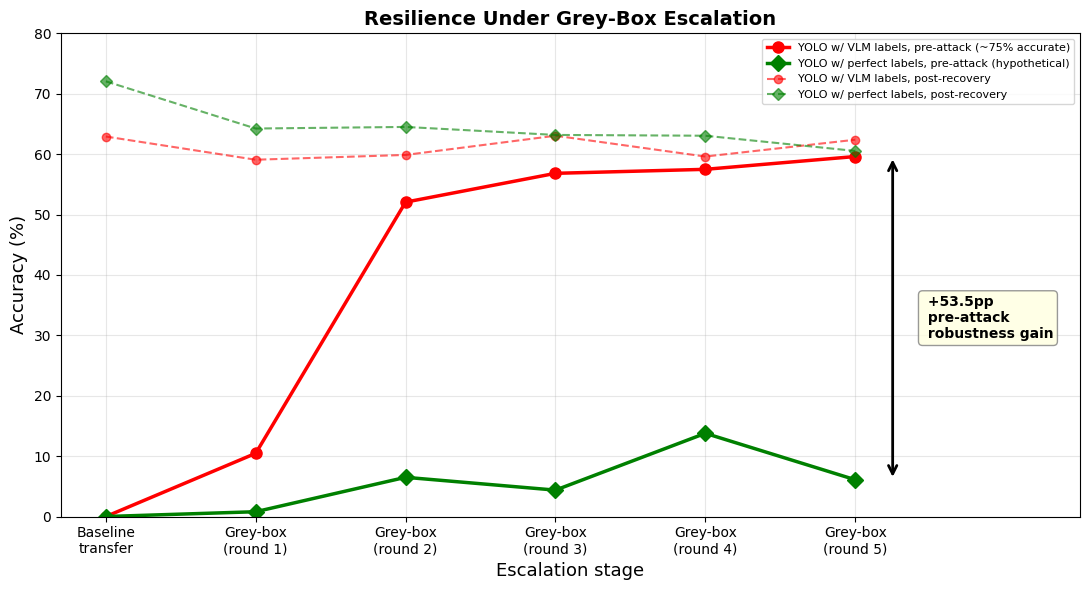


Grey-box escalation results (validation, 759 samples)
Stage                  |  VLM pre  VLM post |  GT pre  GT post |  Pre gap
-------------------------------------------------------------------------------------
Baseline transfer      |     0.0%     62.9% |    0.0%    72.1% |    +0.0pp
Grey-box (round 1)     |    10.5%     59.1% |    0.8%    64.2% |    +9.7pp
Grey-box (round 2)     |    52.1%     59.9% |    6.5%    64.5% |   +45.6pp
Grey-box (round 3)     |    56.8%     63.0% |    4.4%    63.2% |   +52.5pp
Grey-box (round 4)     |    57.5%     59.6% |   13.8%    63.0% |   +43.7pp
Grey-box (round 5)     |    59.6%     62.4% |    6.1%    60.5% |   +53.5pp

Pre-attack = adversarial accuracy before retraining on new attacks.
Post-recovery = adversarial accuracy after VLM/GT-guided retraining.
Pre gap = VLM pre-attack minus GT pre-attack (robustness gain from VLM noise).


In [ ]:
# ── Plot: Pre-attack + Post-recovery ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

stages = [r['stage'] for r in results]
stage_labels = ['Baseline\ntransfer'] + [f'Grey-box\n(round {s})' for s in range(1, N_STAGES)]

# Pre-attack lines (solid)
vlm_same_pre = [r['pre_attack']['adv']*100 for r in results]
ax.plot(stages, vlm_same_pre, 'r-o', label='YOLO w/ VLM labels, pre-attack (~75% accurate)',
        linewidth=2.5, markersize=8)

gt_stages = [r['stage'] for r in gt_results_list]
gt_pre = [r['pre_attack']['adv']*100 for r in gt_results_list]
ax.plot(gt_stages, gt_pre, 'g-D', label='YOLO w/ perfect labels, pre-attack (hypothetical)',
        linewidth=2.5, markersize=8)

# Post-recovery lines (dashed)
vlm_post = [r['post_recovery']['adv']*100 for r in results]
ax.plot(stages, vlm_post, 'r--o', label='YOLO w/ VLM labels, post-recovery',
        linewidth=1.5, markersize=6, alpha=0.6)

gt_post = [r['post_recovery']['adv']*100 for r in gt_results_list]
ax.plot(gt_stages, gt_post, 'g--D', label='YOLO w/ perfect labels, post-recovery',
        linewidth=1.5, markersize=6, alpha=0.6)

n_common = min(len(stages), len(gt_pre))

final_idx = n_common - 1
top_y = vlm_same_pre[final_idx]
bot_y = gt_pre[final_idx]
final_gap = top_y - bot_y
mid_y = (top_y + bot_y) / 2
arrow_x = stages[final_idx] + 0.25

ax.annotate('', xy=(arrow_x, top_y), xytext=(arrow_x, bot_y),
            arrowprops=dict(arrowstyle='<->', color='black', lw=2, mutation_scale=15))
ax.text(arrow_x + 0.2, mid_y, f' +{final_gap:.1f}pp\n pre-attack\n robustness gain',
        fontsize=10, fontweight='bold', va='center', ha='left', color='black',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray', alpha=0.8))

ax.set_xlabel('Escalation stage', fontsize=13)
ax.set_ylabel('Accuracy (%)', fontsize=13)
ax.set_title('Resilience Under Grey-Box Escalation',
             fontsize=14, fontweight='bold')
ax.set_xticks(stages)
ax.set_xticklabels(stage_labels)
ax.set_xlim(-0.3, stages[-1] + 1.5)
ax.set_ylim(0, 80)
ax.legend(fontsize=8, loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('escalation_greybox_final_v3.png', bbox_inches='tight', dpi=300)
plt.show()

# Summary table
print(f'\n{"="*85}')
print(f'Grey-box escalation results (validation, {N_TEST} samples)')
print(f'{"="*85}')
print(f'{"Stage":<22s} | {"VLM pre":>8s} {"VLM post":>9s} | {"GT pre":>7s} {"GT post":>8s} | {"Pre gap":>8s}')
print(f'{"-"*85}')
for i in range(n_common):
    s = stages[i]
    label = 'Baseline transfer' if s == 0 else f'Grey-box (round {s})'
    vp = vlm_same_pre[i]
    vr = vlm_post[i]
    gp = gt_pre[i]
    gr = gt_post[i]
    gap = vp - gp
    print(f'{label:<22s} | {vp:>7.1f}% {vr:>8.1f}% | {gp:>6.1f}% {gr:>7.1f}% | {gap:>+7.1f}pp')

print(f'\nPre-attack = adversarial accuracy before retraining on new attacks.')
print(f'Post-recovery = adversarial accuracy after VLM/GT-guided retraining.')
print(f'Pre gap = VLM pre-attack minus GT pre-attack (robustness gain from VLM noise).')